Loading beam patterns into healpy
---------------------------------

A common use case for diffuse maps is to simulate an antenna's response to the sky, by computing the antenna temperature (i.e. the beam-weighted average of the sky temperature).


In [1]:
import pylab as plt
import pyshtools as pysh
import healpy as hp
import numpy as np
from astropy.coordinates import SkyCoord

Load example beam pattern data from MWA hyperdrive. Data are a 2D numpy array with axes `(zenith_angle, azimuth_angle)`

(90, 360)


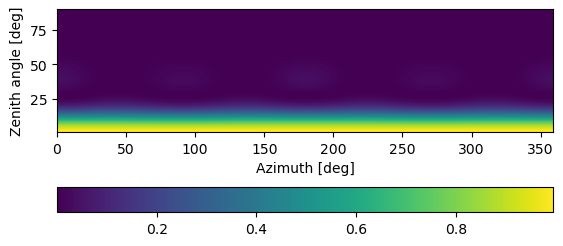

In [2]:
B = np.load('./mwa_beam_example_149.76mhz.npy')
print(B.shape)

az_deg  = np.arange(0, 360)
alt_deg = np.arange(0, 90)
za_deg  = 90 - alt_deg

plt.imshow(B, extent=(az_deg[0], az_deg[-1], za_deg[-1], za_deg[0]))
plt.xlabel("Azimuth [deg]")
plt.ylabel("Zenith angle [deg]")
plt.colorbar(orientation="horizontal")

In [3]:
print(B.max(), B.min())

0.9952251 6.59065e-10


The `pyshtools` package expects data in terms of `(latitude, longitude)`, so flip the zenith angle (which is basically colatitude). Also need to pad to include the other hemisphere.

(180, 360)


/Users/daniel.price/local/mamba/envs/low-uv/lib/python3.11/site-packages/pyshtools/shclasses/shgrid.py:1464: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 640x352 with 1 Axes>,
 <Axes: xlabel='Longitude', ylabel='Latitude'>)

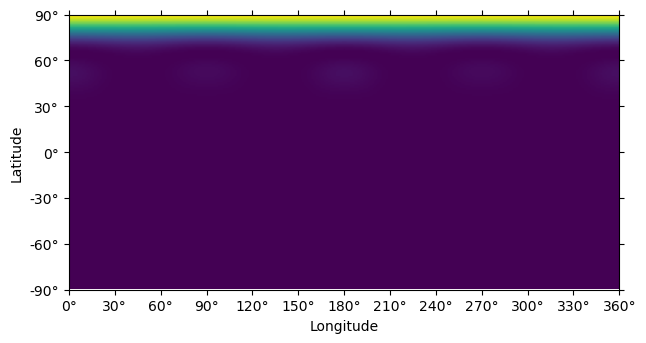

In [4]:
B_padded = np.pad(B[::-1], ((0,90), (0,0)), mode='edge')
print(B_padded.shape)

B      = pysh.SHGrid.from_array(B_padded)
E_clm  = B.expand(normalization='ortho', csphase=-1)

B.plot()

We can also take a look at the spherical harmonic coefficients (if of interest):

/Users/daniel.price/local/mamba/envs/low-uv/lib/python3.11/site-packages/pyshtools/shclasses/shcoeffs.py:3357: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 640x576 with 2 Axes>,
 <Axes: xlabel='Spherical harmonic order', ylabel='Spherical harmonic degree'>)

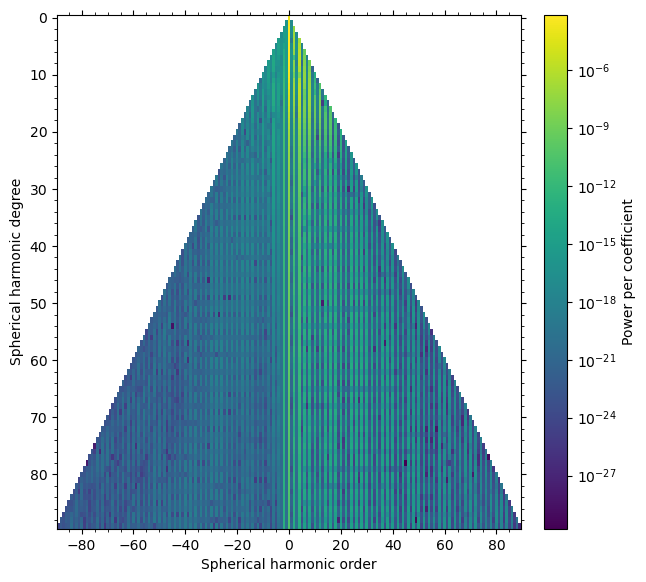

In [5]:
E_clm.plot_spectrum2d()

To test the reconstruction from spherical harmonics, we can reconstruct the input using the same grid points as the original data:

In [6]:
lat_grid, lon_grid = np.meshgrid(B.lats(), B.lons())

reconstructed = pysh.expand.MakeGridPoint(E_clm.coeffs, lat=lat_grid, lon=lon_grid, norm=4)  # norm=4 == ortho

diff = (reconstructed - B_padded.T) / np.max(B_padded)

print(np.max(diff), np.min(diff))

0.0007466812498716666 -0.007396262534634793


While healpix has its own spherical harmonics tools, differences between the conventions used in healpix and pyshtools make direct use of the `E_clm` coefficients difficult (*i.e. I couldn't get it to work!*). Instead, we convert to healpix by evaluating with `pysh.expand.MakeGridPoint` at the lon, lat points for a healpix grid. 

In [7]:
nside = 128

pix_idx  = np.arange(hp.nside2npix(nside))
lon, lat = hp.pix2ang(nside, pix_idx, lonlat=True)

hpx_map = pysh.expand.MakeGridPoint(E_clm.coeffs, lat=lat, lon=lon, norm=4)  # norm=4 == ortho

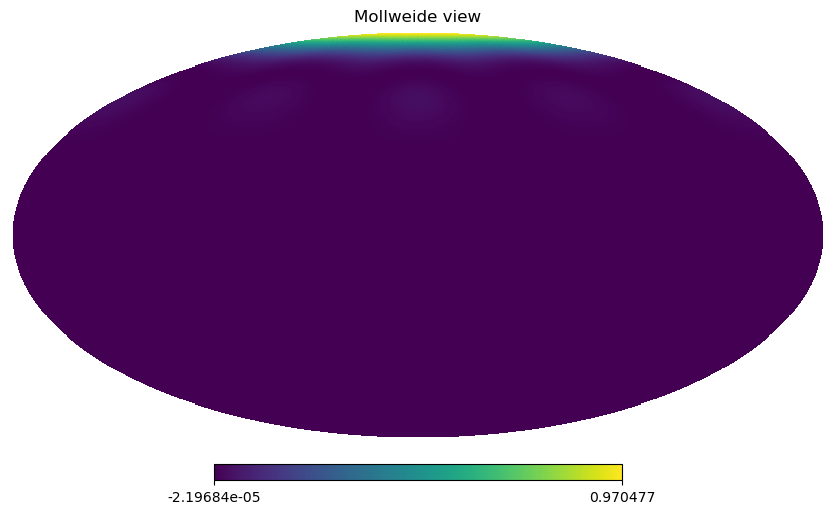

In [8]:
hp.mollview(hpx_map)
plt.show()

Now we can rotate this beam pattern to a desired point on the sky using the healpy utilities:

In [9]:
sky_coord =  SkyCoord('21:27:59.59', '-47:05:40.02', unit=('hourangle', 'deg'))

ll = sky_coord.galactic.l.to('deg').value
bb = sky_coord.galactic.b.to('deg').value
ra = sky_coord.icrs.ra.to('deg').value
dec = sky_coord.icrs.dec.to('deg').value

# If the map needs to be rotated away from alignment with N-E, apply first rotation.
# Healpy uses right-hand rule rotations. A positive rotation about the X-axis
# will tilt the north pole toward -y.
rot_angle=0
if rot_angle > 0:
    r0r = hp.rotator.Rotator(rot=[rot_angle + 90, 0, 0], coord=None, eulertype='X')
    hpx_map = r0r.rotate_map_alms(hpx_map)

# Next rotation: from (theta,phi) to (alt, az)
# To convert (theta, phi) antenna coords to (alt, az) astro coords:
#     az = 90 - phi
# To convert to Galactic coords (l, b) also requires 90 degree shift:
#     b = 90 - phi
r0 = hp.rotator.Rotator(rot=[0, 90, 0], coord=None, eulertype='Y')
hpx_map = r0.rotate_map_alms(hpx_map)

# Third rotation - to sky coordinate (RA / DEC)
r1 = hp.Rotator(rot=[ra, dec], coord=['G', 'C'], inv=True)
hpx_map = r1.rotate_map_alms(hpx_map)

# Create a masked array so we can mask below horizon
mask = np.ones(shape=hpx_map.shape[0], dtype='bool')

# Now create below horizon mask
# ang2vec takes longitude and latitude in degrees when lonlat=True
vec = hp.ang2vec(ll, bb, lonlat=True)
ipix = hp.query_disc(nside=nside, vec=vec, radius=0.99 * np.pi / 2)  # Mask very edge pixels
mask[ipix] = 0

hpx_map = np.ma.array(hpx_map)
hpx_map.mask = mask
hpx_map.fill_value = np.nan   # Can also use np.nan or 1e20


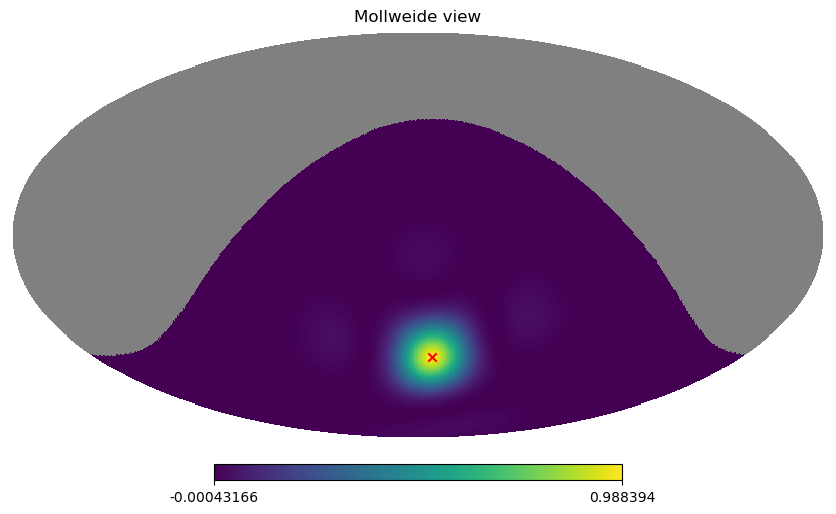

In [10]:
hp.mollview(hpx_map)
hp.projscatter(ll, bb, marker='x', color='red', lonlat=True)
plt.show()


### Dealing with polarized beam patterns

A code snippet that may be helpful:

```python

# First, load data for Etheta and Ephi

# Jones matrix consists of Etheta, Ephi for X and Y pol
J = np.array(((Etheta_x, Ephi_x), (Etheta_y, Ephi_y)))

# Convert to a linear polarization coherency matrix by taking the outer product
C_mat = np.matmul(J, np.conjugate(J))

# Alternatively, if you have an array with lat, lon axes already
C_mat = np.einsum('abpq,abqp->abpq', J.reshape((90, 360, 2, 2)), np.conjugate(J.reshape((90, 360, 2, 2))))

# Extract real-valued arrays
C = {
    'xx':   np.real(C_mat[..., 0, 0]),
    're_xy': np.real(C_mat[..., 0, 1]),
    'im_xy': np.imag(C_mat[..., 0, 1]),
    'yy':    np.real(C_mat[..., 1, 0]),
}

# Convert linear polarization to Stokes parameters
S = {
    'I': C['xx'] + C['yy'],
    'Q': C['xx'] - C['yy'],
    'U': 2 * C['re_xy'],
    'V': 2 * C['im_xy']
}
```